In [23]:
import csv
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [24]:
!pip install scikit-learn
!pip install seaborn

python(17630) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(17631) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 19.8 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [seaborn]m3/4 [seaborn]


In [25]:
# Load label names from label.csv
import csv

label_path = "dataset/label.csv"
class_names = []

with open(label_path, "r") as f:
    reader = csv.reader(f)
    for row in reader:
        class_names.append(row[0])

print("Loaded class names:", class_names)


Loaded class names: ['FIST', 'POINT', 'PEACE', 'THUMBS_UP', 'THUMBS_DOWN']


# Dataset

In [26]:
class KeypointDataset(Dataset):
    def __init__(self, csv_path):
        self.samples = []
        with open(csv_path, "r") as f:
            reader = csv.reader(f)
            for row in reader:
                label = int(row[0])
                points = list(map(float, row[1:]))
                self.samples.append((points, label))

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        points, label = self.samples[idx]
        points = torch.tensor(points, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)
        return points, label


# Model

In [27]:
# Initialize the model
from keypoint_classifier import KeyPointModel
from sklearn.model_selection import train_test_split

# Train

In [28]:
loss_history = []
acc_history = []

# Paths
dataset_path = "dataset/keypoint.csv"
# Load full dataset
full_dataset = KeypointDataset(dataset_path)

# Extract labels from your dataset for stratified splitting
all_labels = [label for _, label in full_dataset.samples]

# Create train/test indices (80% train, 20% test)
train_idx, test_idx = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.2,
    shuffle=True,
    stratify=all_labels
)

# Create subset datasets
train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
test_dataset  = torch.utils.data.Subset(full_dataset, test_idx)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

NUM_CLASSES = len(set(all_labels))

device = "cuda" if torch.cuda.is_available() else "cpu"

model = KeyPointModel(NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 100

for epoch in range(EPOCHS):
	total_loss = 0
	total_correct = 0
	total_samples = 0
	
	for points, labels in train_loader:
		points, labels = points.to(device), labels.to(device)
		
		optimizer.zero_grad()
		
		logits = model(points)
		loss = nn.functional.cross_entropy(logits, labels)
		
		loss.backward()
		optimizer.step()

		preds = torch.argmax(logits, dim=1)
		total_correct += (preds == labels).sum().item()
		total_samples += labels.size(0)
		
		total_loss += loss.item()
	
	epoch_loss = total_loss / len(train_loader)
	epoch_acc = total_correct / total_samples

	loss_history.append(epoch_loss)
	acc_history.append(epoch_acc)

	print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

model_save_path = "keypoint_model.pth"
torch.save(model.state_dict(), model_save_path)

Epoch 1/100  Loss: 1.6251  Acc: 0.2500
Epoch 2/100  Loss: 1.6134  Acc: 0.2000
Epoch 3/100  Loss: 1.6126  Acc: 0.2833
Epoch 4/100  Loss: 1.5995  Acc: 0.2000
Epoch 5/100  Loss: 1.5931  Acc: 0.2250
Epoch 6/100  Loss: 1.5853  Acc: 0.2417
Epoch 7/100  Loss: 1.5708  Acc: 0.2750
Epoch 8/100  Loss: 1.5692  Acc: 0.2750
Epoch 9/100  Loss: 1.5533  Acc: 0.2833
Epoch 10/100  Loss: 1.5490  Acc: 0.3000
Epoch 11/100  Loss: 1.5328  Acc: 0.3583
Epoch 12/100  Loss: 1.5303  Acc: 0.3333
Epoch 13/100  Loss: 1.5008  Acc: 0.3583
Epoch 14/100  Loss: 1.4878  Acc: 0.3667
Epoch 15/100  Loss: 1.4717  Acc: 0.3583
Epoch 16/100  Loss: 1.4478  Acc: 0.3917
Epoch 17/100  Loss: 1.4685  Acc: 0.3250
Epoch 18/100  Loss: 1.4125  Acc: 0.3583
Epoch 19/100  Loss: 1.3934  Acc: 0.3833
Epoch 20/100  Loss: 1.3863  Acc: 0.3833
Epoch 21/100  Loss: 1.3530  Acc: 0.4333
Epoch 22/100  Loss: 1.2955  Acc: 0.4667
Epoch 23/100  Loss: 1.2979  Acc: 0.3917
Epoch 24/100  Loss: 1.2569  Acc: 0.4167
Epoch 25/100  Loss: 1.2592  Acc: 0.4417
Epoch 26/

# Loss Curve and Accuracy Curve

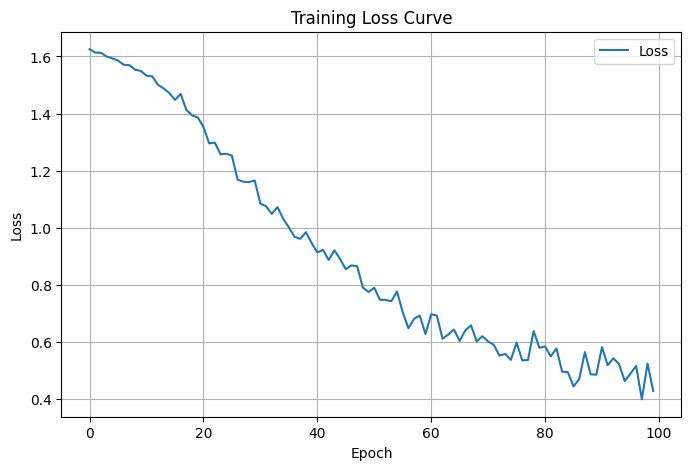

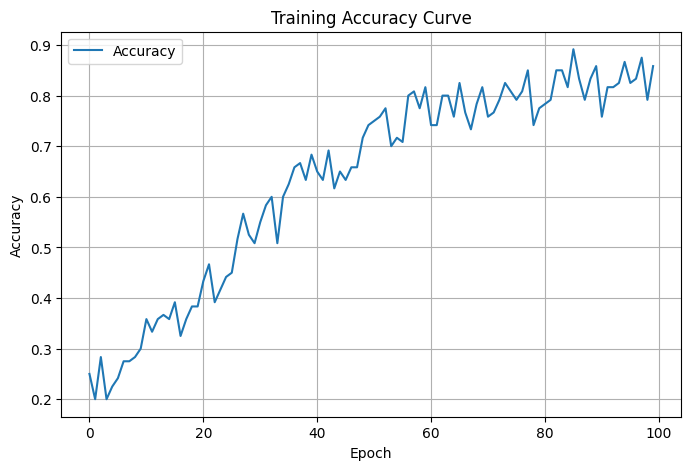

In [29]:
# Loss Curve
plt.figure(figsize=(8,5))
plt.plot(loss_history, label="Loss")
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(acc_history, label="Accuracy")
plt.title("Training Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# Test Accuracy

In [30]:
model.eval()
test_correct = 0
test_total = 0
all_preds = []
all_true = []

with torch.no_grad():
    for points, labels in test_loader:
        points, labels = points.to(device), labels.to(device)

        logits = model(points)
        preds = torch.argmax(logits, dim=1)

        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

test_accuracy = test_correct / test_total
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9333333333333333


# Confusion Matrix

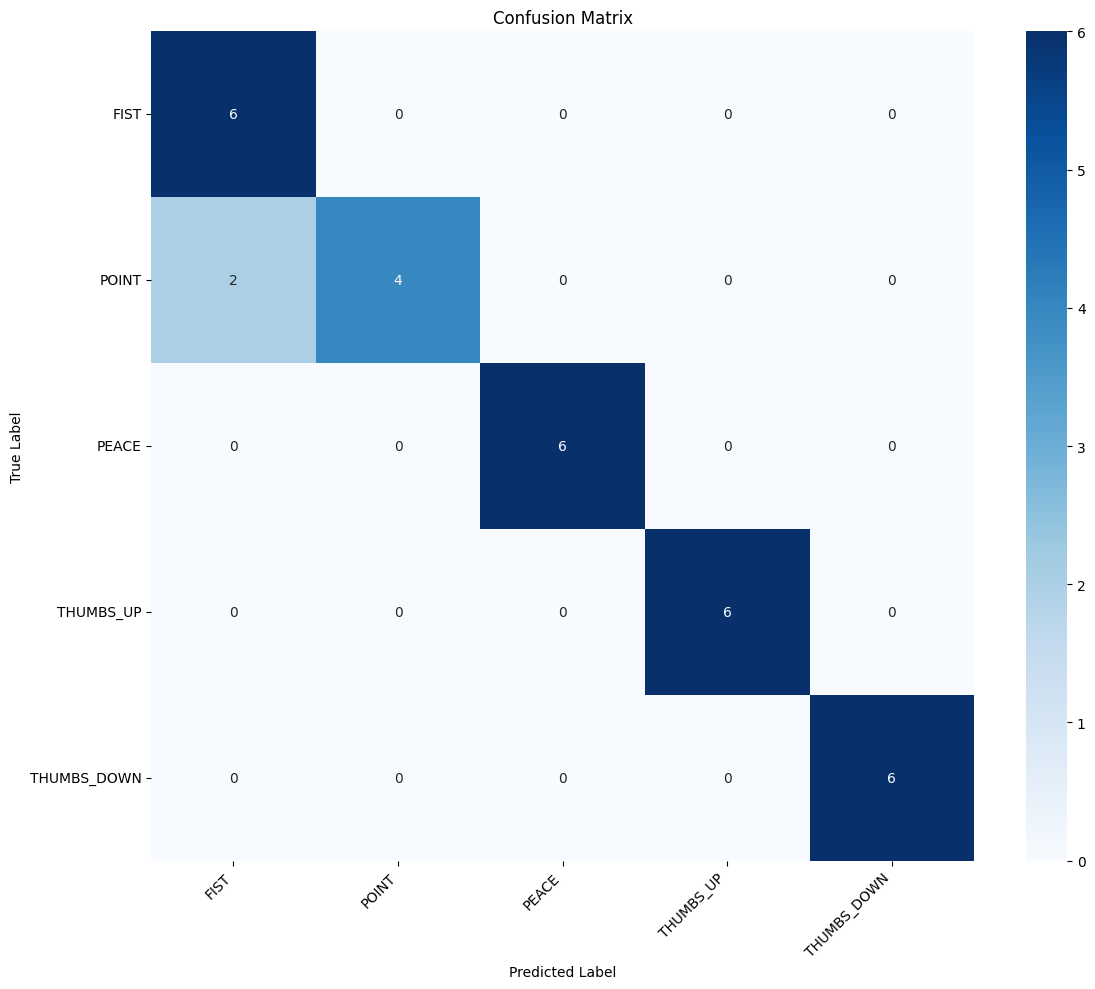

In [31]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Per-class Accuracy Bar Chart

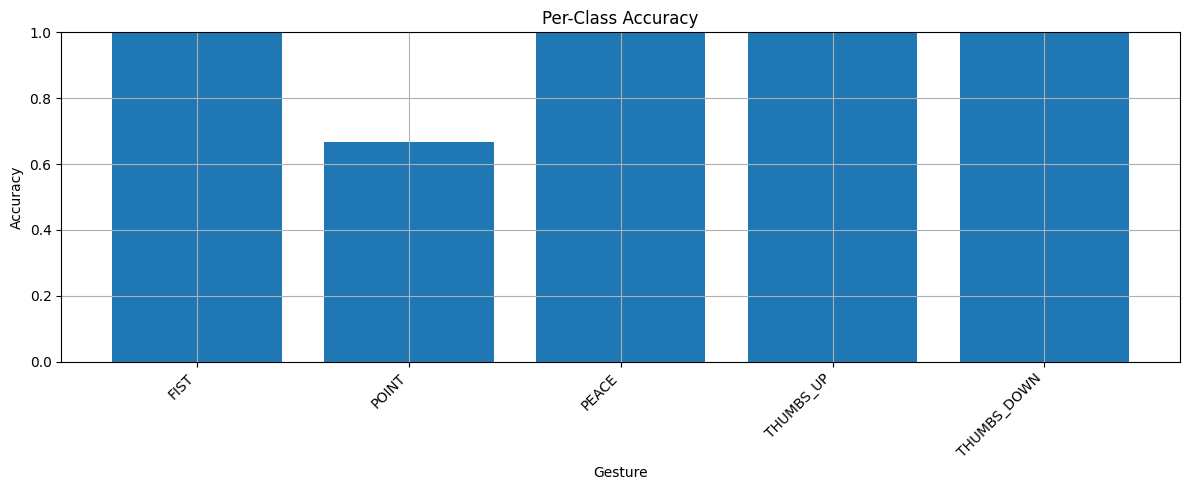

FIST: 1.000
POINT: 0.667
PEACE: 1.000
THUMBS_UP: 1.000
THUMBS_DOWN: 1.000


In [32]:
num_classes = NUM_CLASSES
correct_per_class = np.zeros(num_classes)
total_per_class = np.zeros(num_classes)

for true, pred in zip(all_true, all_preds):
    if true == pred:
        correct_per_class[true] += 1
    total_per_class[true] += 1

class_accuracy = correct_per_class / total_per_class

plt.figure(figsize=(12, 5))
plt.bar(class_names, class_accuracy)
plt.title("Per-Class Accuracy")
plt.xlabel("Gesture")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

for name, acc in zip(class_names, class_accuracy):
    print(f"{name}: {acc:.3f}")
